<h1><center>Laboratorio 10: Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2024</strong></center>

### **Cuerpo Docente:**

- Profesores: Ignacio Meza, Sebastián Tinoco
- Auxiliar: Eduardo Moya
- Ayudantes: Nicolás Ojeda, Melanie Peña, Valentina Rojas

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Sofía Lazcano Madrid
- Nombre de alumno 2: María Jesús Espinoza


### **Link de repositorio de GitHub:** https://github.com/jesuow/LabPro

### Indice

1. [Temas a tratar](#Temas-a-tratar:)
3. [Descripcción del laboratorio](#Descripción-del-laboratorio.)
4. [Desarrollo](#Desarrollo)

## Temas a tratar

- Clasificación usando `XGBoost`.
- Métodos Agnósticos Globales de Interpretabilidad (`Partial Dependence Plot`, `Permutation Feature Importance`)
- Métodos Agnósticos Locales de Interpretabilidad (`Scoped Rules`, `SHAP`)

## Reglas:

- **Grupos de 2 personas**
- Asistencia **obligatoria** a instrucciones del lab (viernes 16.15). Luego, pueden quedarse trabajando en las salas o irse.
- **No se revisarán entregas de personas ausentes**.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias.
- Pueden usar cualquer matrial del curso que estimen conveniente.

### Objetivos principales del laboratorio

- Generar un pipeline de clasificación con `XGBoost`.
- Implementar modelos de interpretabilidad para explicar el funcionamiento del modelo de clasificación.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# 1. Problemas Clínicos del Dr. Simi

<p align="center">
  <img src="https://gantz.cl/wp-content/uploads/2020/01/79024136_2718114448239059_7240913062570491904_o.jpg" width="350">
</p>

El reconocido **Dr. Simi**, famoso vendedor de medicamentos en latinoamerica, debido a la creciente prevalencia de enfermedades crónicas, como la diabetes, decidió abrir una clínica especializada en el tratamiento de esta enfermedad en nuestro país.

La clínica del Doctor Simi se convirtió en un lugar donde los pacientes con diabetes podrían recibir atención médica integral. El personal médico estaba compuesto por especialistas en endocrinología, nutrición y enfermería, todos capacitados en el manejo de la diabetes.

Sin embargo él se ha dado cuenta que los tiempos han cambiado y gracias a las tecnologías es posible generar mejores predicciones en la diabetes conociendo el historial médico de las personas. Por esto, el doctor se ha colocado una meta de incluir modelos de machine learning dentro de sus clínicas, para ello le ha solicitado crear un modelo capaz de predecir/clasificar diabetes pero le rogó que el desarrollo del modelo tuviera un especial enfoque en la interpretabilidad de lo que hace su modelo.

Para que usted pueda entrenar el modelo, Dr. Simi le ha entregado un dataset de todos los clientes que fueron detectados con diabetes a lo largo de la historia de la clinica. Con ello, adjunta el historial médico de las personas en forma de datos tabulares para que usted pueda realizar fácilmente la clasificación.


In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('diabetes_data.csv')
df.head(5)

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Clasificación de pacientes con diabetes (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/QH--g3ZaSbsAAAAC/dr-simi-abrazo.gif" width="400">
</p>

Tareas:
1. En primer lugar, el reconocido doctor le pide entrenar un modelo de `XGBoost` utilizando como target la columna `Diabetes` del dataset `diabetes_data.csv`. Para el entrenamiento, realice los siguientes pasos:
  * Realice una breve exploración de los datos y determine si aplicará transformaciones (MinMaxScaler, StandardScaler, etc.) en alguna/s de las variables. (1 punto)
  * Cree un conjunto de entrenamiento y uno de prueba, con una proporción de 1/3 en el conjunto de prueba. (0.5 puntos)
  * Cree un ColumnTransformer de preprocesamiento donde aplique las transformaciones determinadas anteriormente. Fije el parámetro `verbose_feature_names_out=False` y fije la salida del ColumnTransformer en formato pandas mediante el método `.set_output(transform='pandas')`. (1 punto)
  *  Cree un pipeline donde integre el preprocesamiento y el modelo `XGBoost` y entrene el modelo. Luego utilice `classification_report(..)` para reportar el desempeño del modelo. (1 punto)

Comente sus decisiones y los resultados obtenidos con el modelo.

2. Luego, le pide responder las siguientes preguntas:
  *  ¿Es acaso un buen predictor de diabetes? (0.5 puntos)
  * ¿Qué buscan explicar las métricas utilizadas? (0.5 puntos)
  * ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?(0.5 puntos)

In [ ]:
!pip install xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 9.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 23.1.2
[notice] To update, run: pip install --upgrade pip


    Age  Sex  HighChol  CholCheck   BMI  Smoker  HeartDiseaseorAttack  \
0   4.0  1.0       0.0        1.0  26.0     0.0                   0.0   
1  12.0  1.0       1.0        1.0  26.0     1.0                   0.0   
2  13.0  1.0       0.0        1.0  26.0     0.0                   0.0   
3  11.0  1.0       1.0        1.0  28.0     1.0                   0.0   
4   8.0  0.0       0.0        1.0  29.0     1.0                   0.0   

   PhysActivity  Fruits  Veggies  HvyAlcoholConsump  GenHlth  MentHlth  \
0           1.0     0.0      1.0                0.0      3.0       5.0   
1           0.0     1.0      0.0                0.0      3.0       0.0   
2           1.0     1.0      1.0                0.0      1.0       0.0   
3           1.0     1.0      1.0                0.0      3.0       0.0   
4           1.0     1.0      1.0                0.0      2.0       0.0   

   PhysHlth  DiffWalk  Stroke  HighBP  Diabetes  
0      30.0       0.0     0.0     1.0       0.0  
1       0.0     

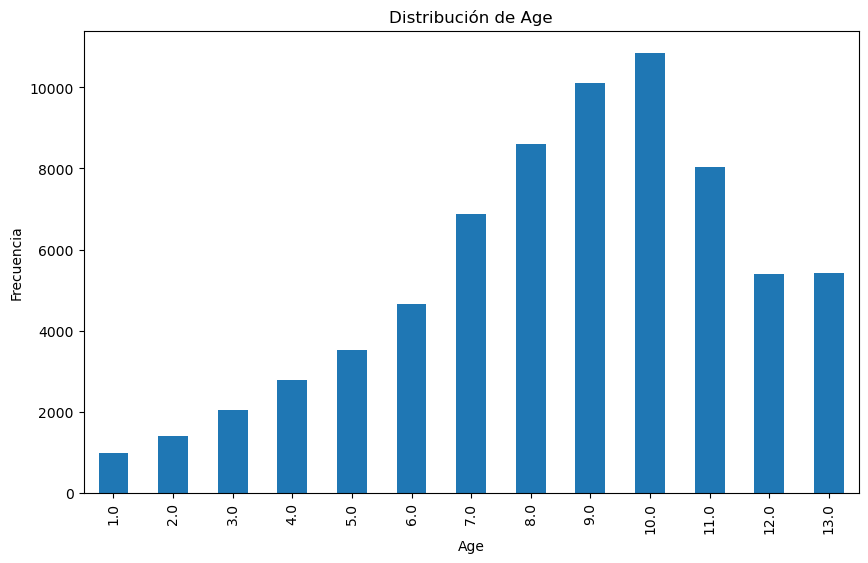

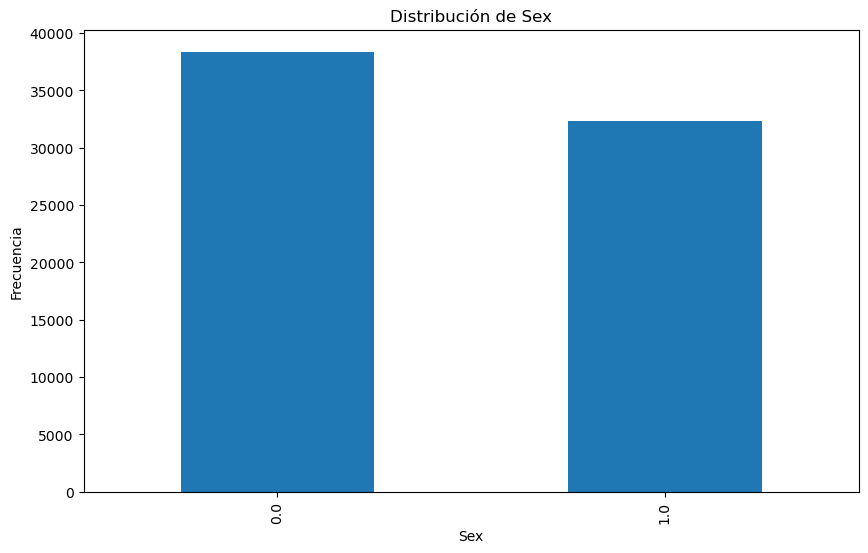

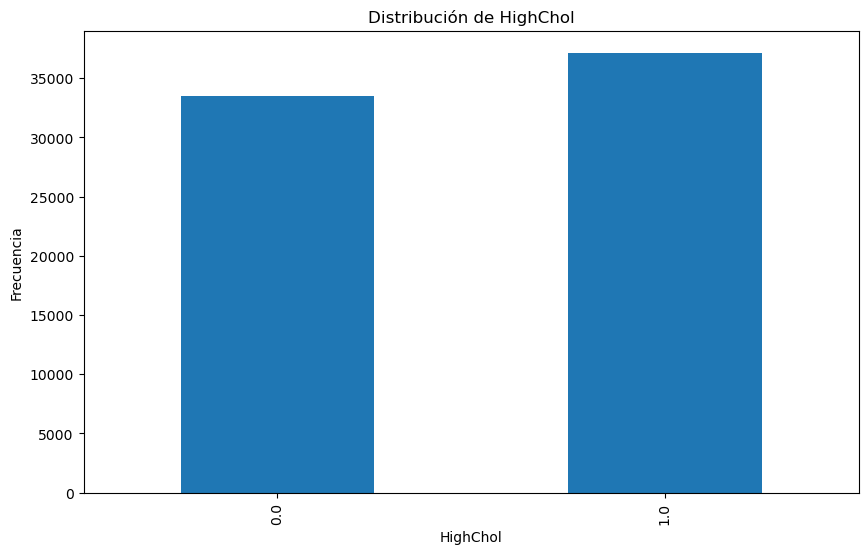

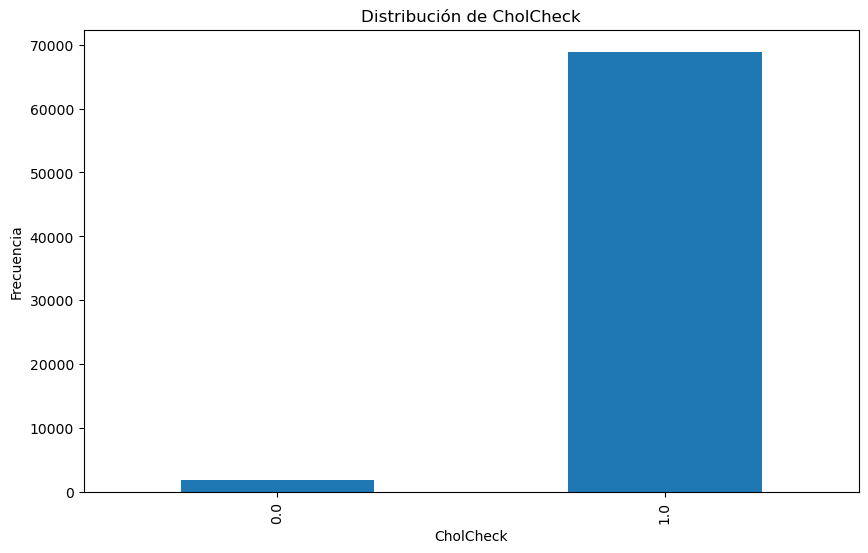

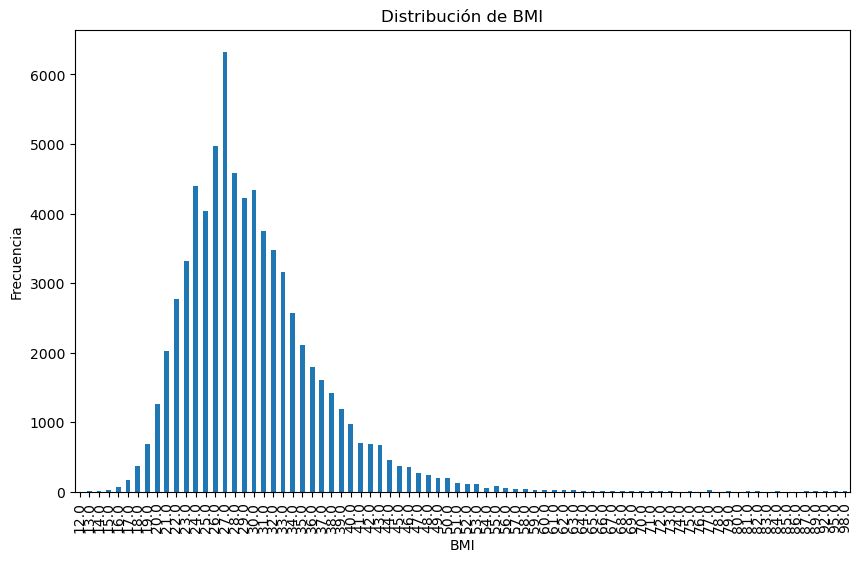

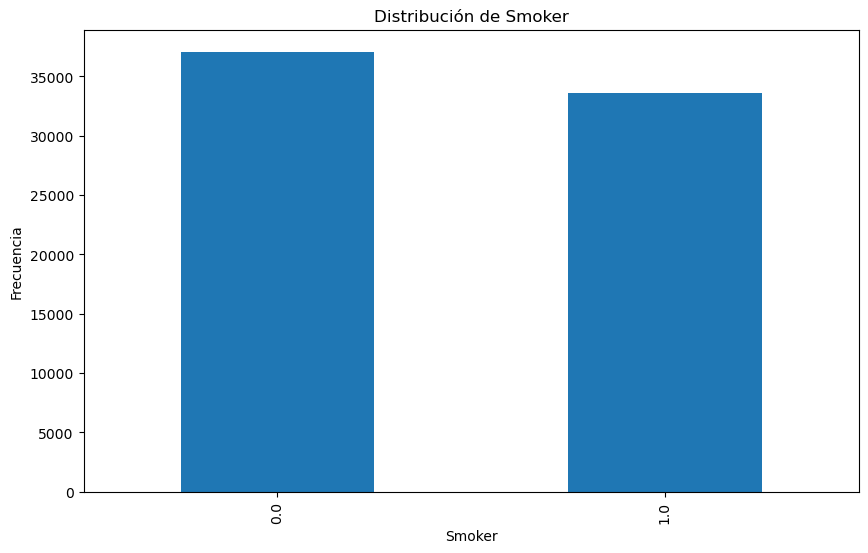

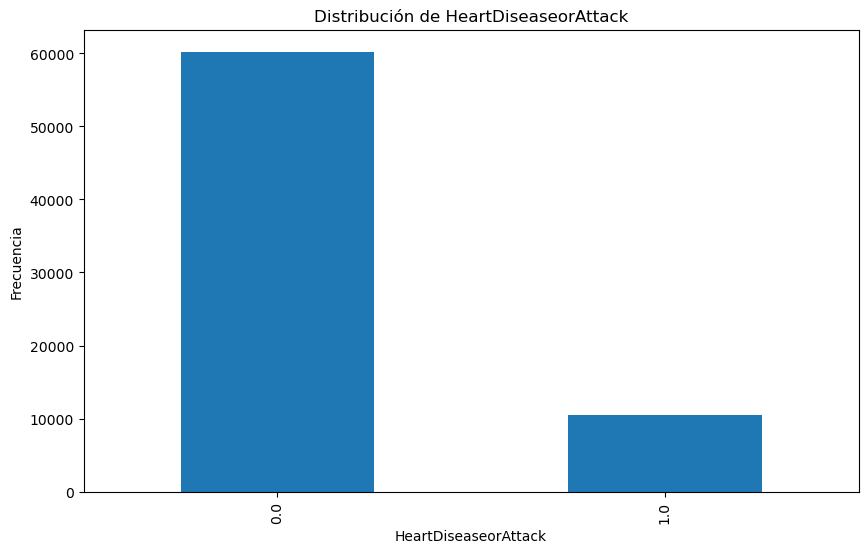

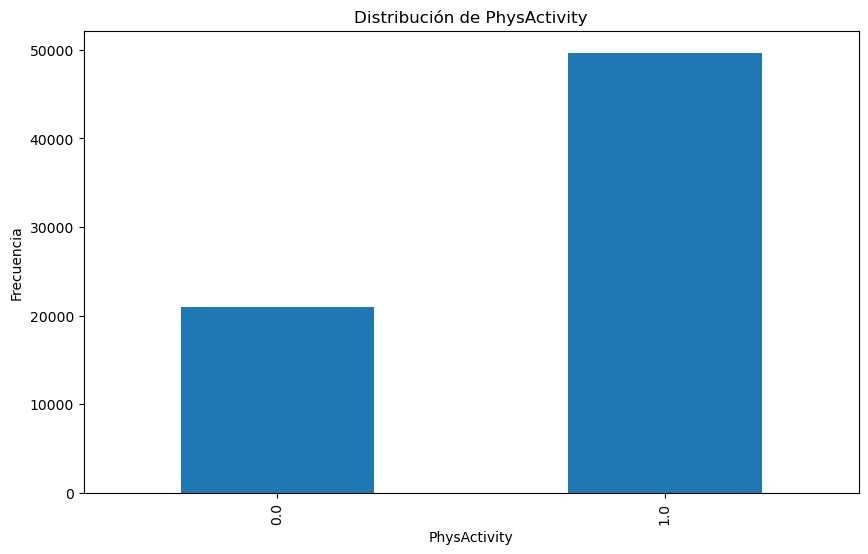

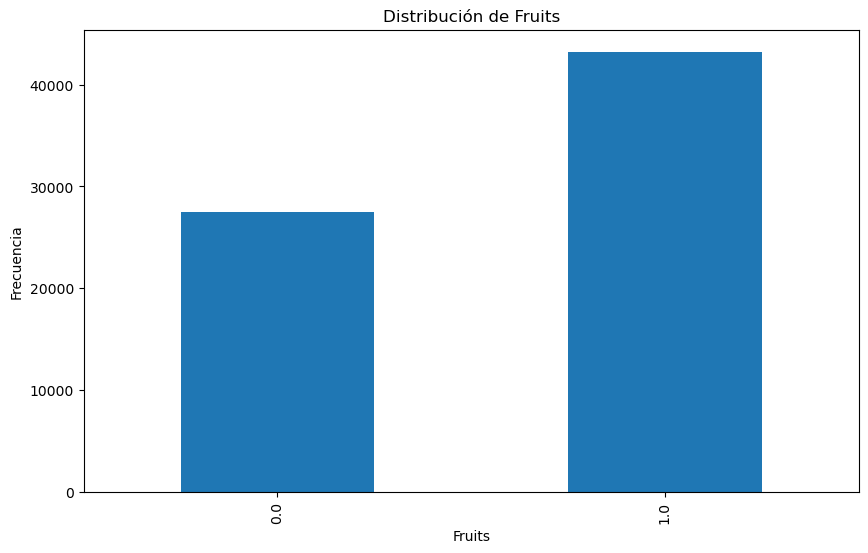

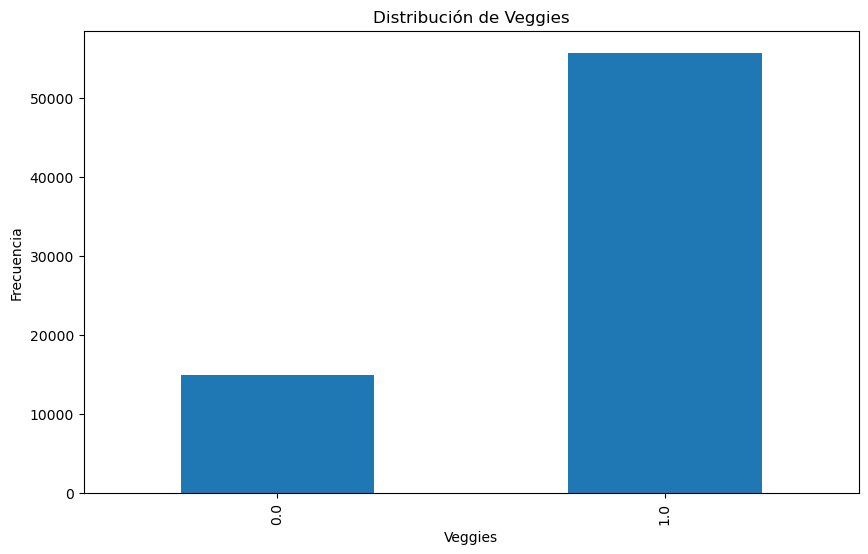

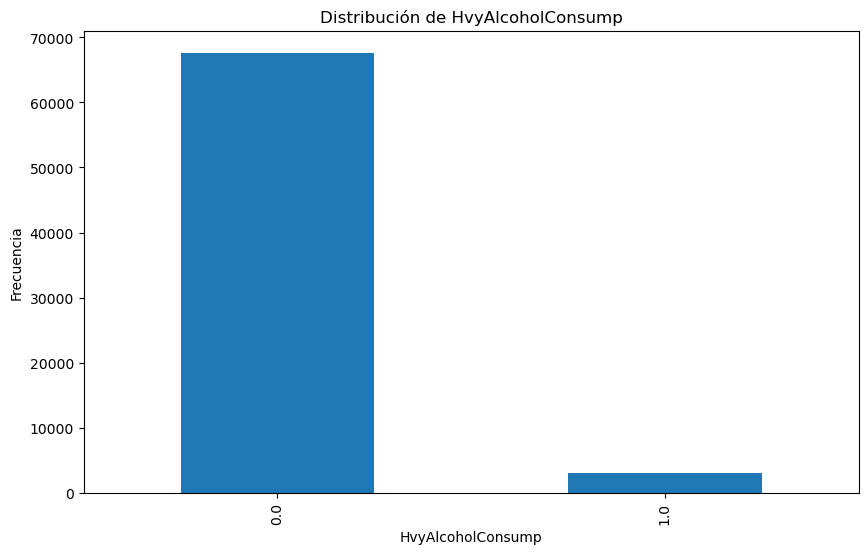

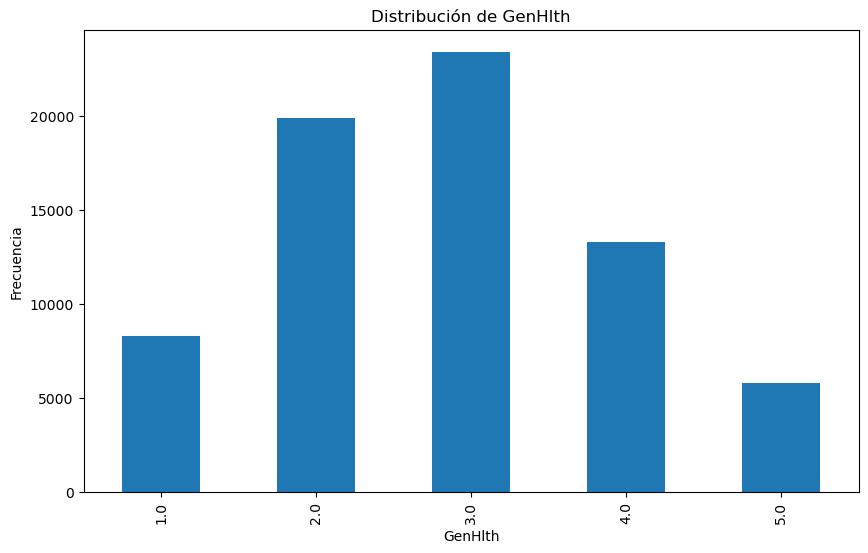

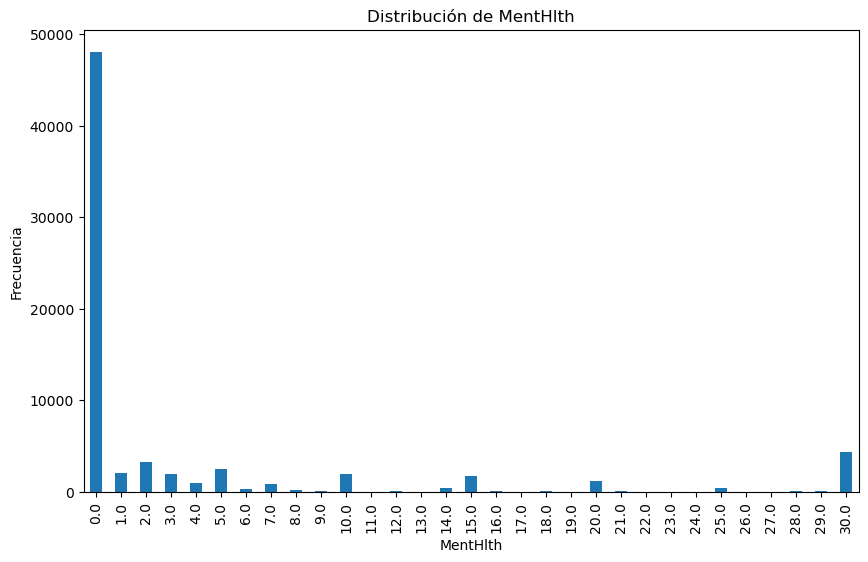

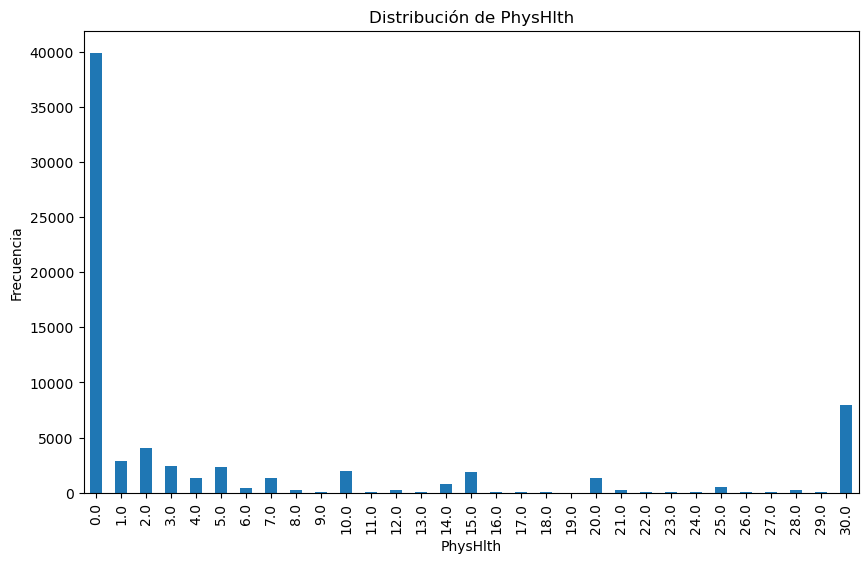

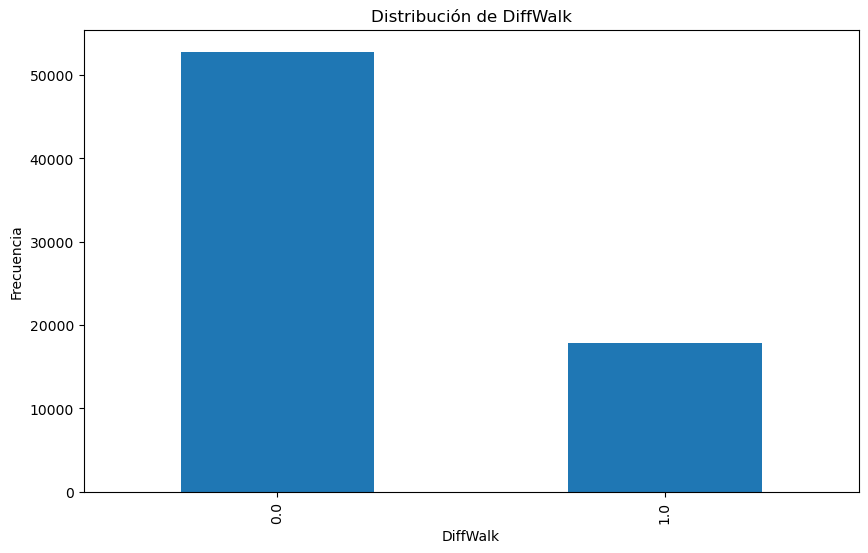

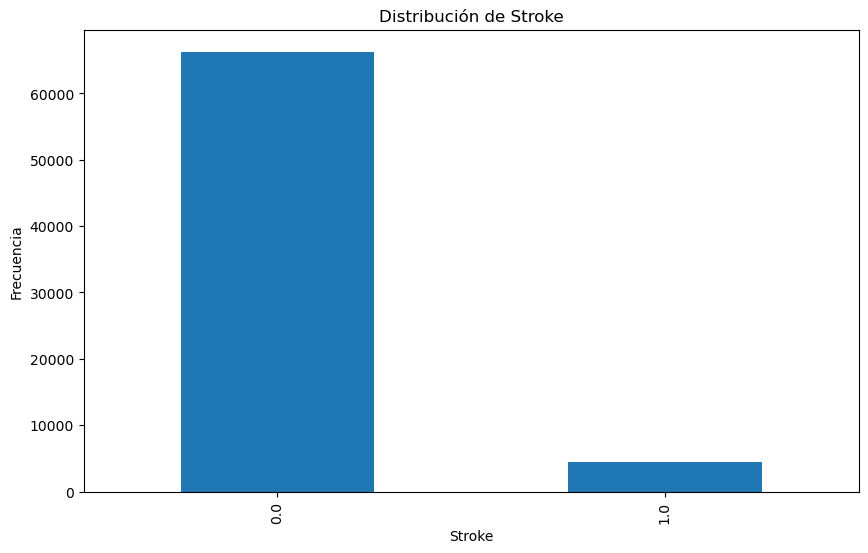

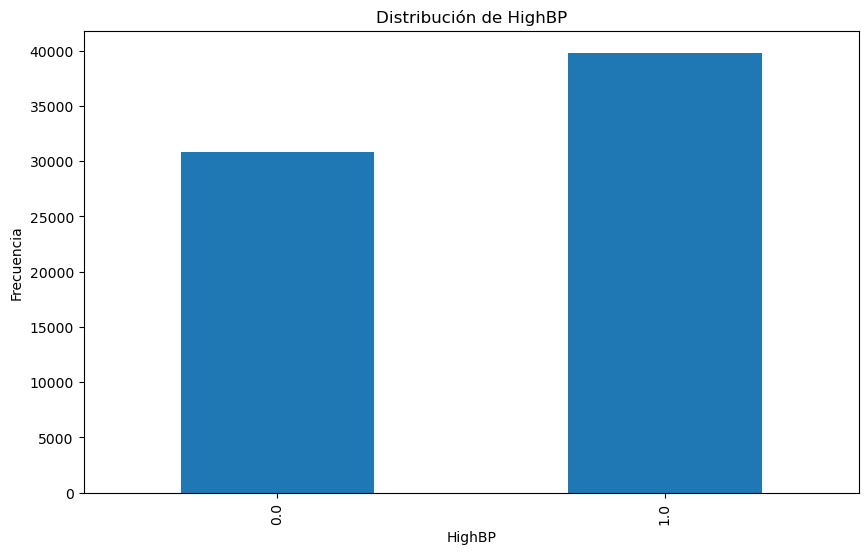

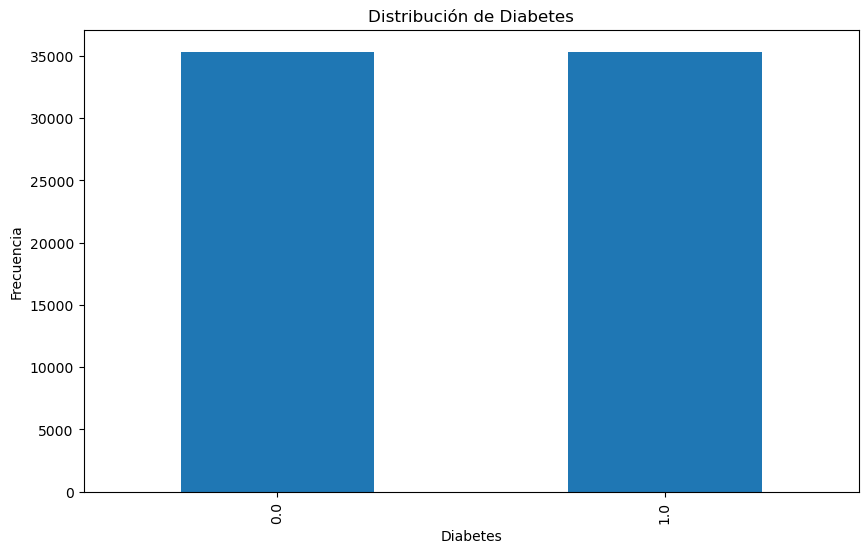

/home/toti/miniconda3/envs/MDS/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [22:22:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Exactitud: 0.7512140192835527
Precisión: 0.7310561444837064
Sensibilidad (Recall): 0.79054627795075
Puntaje F1: 0.7596382674916706
Matriz de Confusión:
[[5088 2055]
 [1480 5586]]
Informe de Clasificación:
              precision    recall  f1-score   support

         0.0       0.77      0.71      0.74      7143
         1.0       0.73      0.79      0.76      7066

    accuracy                           0.75     14209
   macro avg       0.75      0.75      0.75     14209
weighted avg       0.75      0.75      0.75     14209



In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

# Cargar y mostrar los datos
data = pd.read_csv("diabetes_data.csv")
print(data.head())

# Visualizar la distribución de cada columna
for feature in data.columns:
    plt.figure(figsize=(10, 6))
    counts = data[feature].value_counts().sort_index()
    counts.plot(kind="bar")
    plt.title(f"Distribución de {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frecuencia")
    plt.show()

# Separar en características (X) y variable objetivo (y)
X_features = data.drop(columns=["Diabetes"])
y_target = data["Diabetes"]

# Dividir los datos en conjunto de entrenamiento (70%) y un conjunto temporal (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X_features, y_target, test_size=0.3, random_state=42)

# Dividir el conjunto temporal en validación (20%) y prueba (10%)
X_validation, X_test, y_validation, y_test = train_test_split(X_temp, y_temp, test_size=0.33, random_state=42)

# Identificar las columnas numéricas
numerical_columns = X_features.columns

# Configurar el preprocesador
data_preprocessor = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numerical_columns)
    ]
)

# Crear el pipeline con XGBClassifier
classification_pipeline = Pipeline(steps=[
    ("preprocessing", data_preprocessor),
    ("xgb_model", XGBClassifier(use_label_encoder=False, eval_metric="logloss"))
])

# Entrenar el pipeline
classification_pipeline.fit(X_train, y_train)

# Hacer predicciones con el conjunto de validación
y_pred_validation = classification_pipeline.predict(X_validation)

# Calcular las métricas de rendimiento
acc = accuracy_score(y_validation, y_pred_validation)
prec = precision_score(y_validation, y_pred_validation)
rec = recall_score(y_validation, y_pred_validation)
f1 = f1_score(y_validation, y_pred_validation)

# Mostrar las métricas
print(f"Exactitud: {acc}")
print(f"Precisión: {prec}")
print(f"Sensibilidad (Recall): {rec}")
print(f"Puntaje F1: {f1}")

# Matriz de confusión
matrix = confusion_matrix(y_validation, y_pred_validation)
print(f"Matriz de Confusión:\n{matrix}")

# Informe de clasificación detallado
classification_report_output = classification_report(y_validation, y_pred_validation)
print(f"Informe de Clasificación:\n{classification_report_output}")


¿El modelo es un buen predictor de diabetes?

Para evaluar si el modelo predice adecuadamente la diabetes, es necesario analizar las métricas de rendimiento y su significado:

Precisión (Accuracy: 0.751):
El modelo acierta en un 75.1% de las predicciones. Aunque esto parece razonable, la precisión global puede ser engañosa si el conjunto de datos está desbalanceado, lo que en este caso no es un problema, ya que las clases están equilibradas. Sin embargo, es importante considerar otras métricas.

Precisión (Precision: 0.731 para la clase positiva):
El 73.1% de los casos predichos como positivos (diabetes) son verdaderos positivos. Esta métrica es relevante cuando queremos minimizar los falsos positivos, por ejemplo, cuando una clasificación incorrecta podría tener consecuencias importantes.

Sensibilidad (Recall: 0.791 para la clase positiva):
El modelo identifica correctamente el 79.1% de los casos positivos de diabetes. Un alto recall es vital cuando es crucial no perder casos positivos, como en el diagnóstico médico, donde los falsos negativos pueden ser muy perjudiciales.

Puntaje F1 (F1 Score: 0.760 para la clase positiva):
El F1 Score, al ser una media armónica entre precisión y recall, muestra que el modelo logra un buen equilibrio entre ambas métricas, con un valor de 0.760. Esto sugiere que el modelo tiene un rendimiento adecuado y balanceado.

En resumen, el modelo muestra un desempeño aceptable, pero hay margen para mejoras en sus predicciones.

Significado de las métricas:
Precisión (Accuracy): Indica el porcentaje de predicciones correctas sobre el total. Es útil como un indicador general, pero puede no reflejar adecuadamente el rendimiento en casos desbalanceados.
Precisión (Precision): Mide la proporción de verdaderos positivos sobre todas las predicciones positivas. Es importante en situaciones donde los falsos positivos deben ser minimizados.
Sensibilidad (Recall): Calcula la proporción de verdaderos positivos sobre el total de casos positivos reales. Es esencial cuando es crucial detectar todos los casos positivos.
Puntaje F1 (F1 Score): Combina precisión y sensibilidad en un solo valor, útil cuando se necesita un equilibrio entre ambas.
Matriz de Confusión: Proporciona un desglose detallado de las predicciones correctas e incorrectas, ofreciendo una visión clara del desempeño por clase.
Informe de Clasificación (Classification Report): Resumen que detalla precisión, sensibilidad y F1 Score para cada clase, además de promedios generales.
¿Garantizan las métricas una buena elección de las características?
Aunque las métricas indican el rendimiento del modelo, no aseguran directamente que las características seleccionadas sean óptimas. Sin embargo, buenos resultados sugieren que las características elegidas son útiles para la tarea de clasificación. La selección de características puede optimizarse aún más mediante técnicas adicionales de análisis y prueba.

## 3. Importancia de las features con XGBoost (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/5JAj5_IiagEAAAAd/dr-simi-dr-simi-dance.gif" width="400">
</p>

Tareas:
1. Para añadir el toque de interpretabilidad que Dr. Simi le pide, se le pide calcular la **importancia de las features** del modelo entrenado utilizando todos los métodos (*weight*, *cover*, *gain*) que posee xgboost usando `plot_importance`. `Hint:` Puede acceder a un paso de un pipeline por su nombre mediante el método `.named_steps[...]` (3 puntos)
2. ¿Los resultados obtenidos con los diferentes métodos son compatibles?, comente sus resultados y a que se debe la igualdad o desigualdad que ve en los resultados. (1 punto)
3. Finalmente, ¿las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método? (1 punto)

<Figure size 1000x800 with 0 Axes>

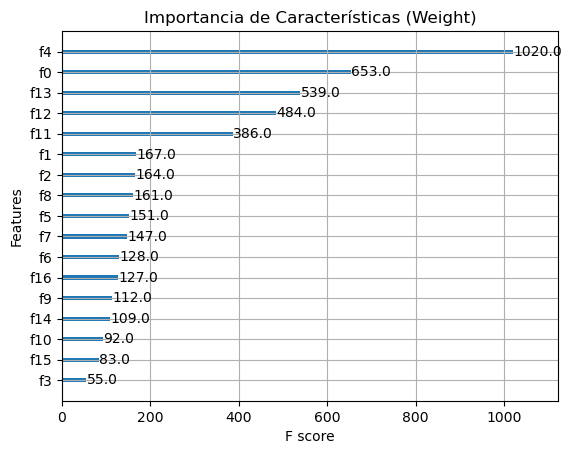

<Figure size 1000x800 with 0 Axes>

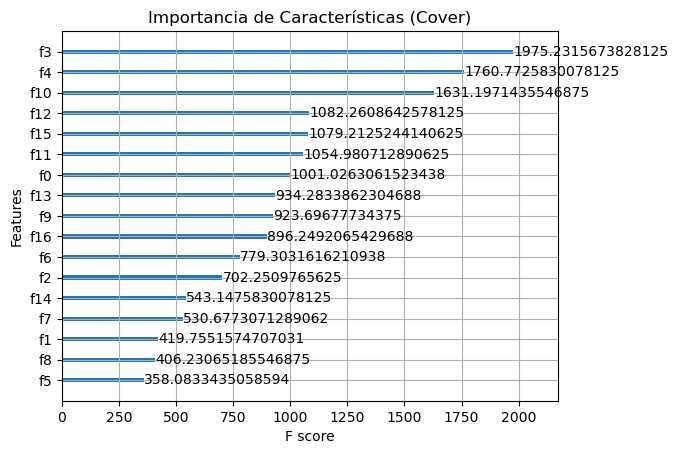

<Figure size 1000x800 with 0 Axes>

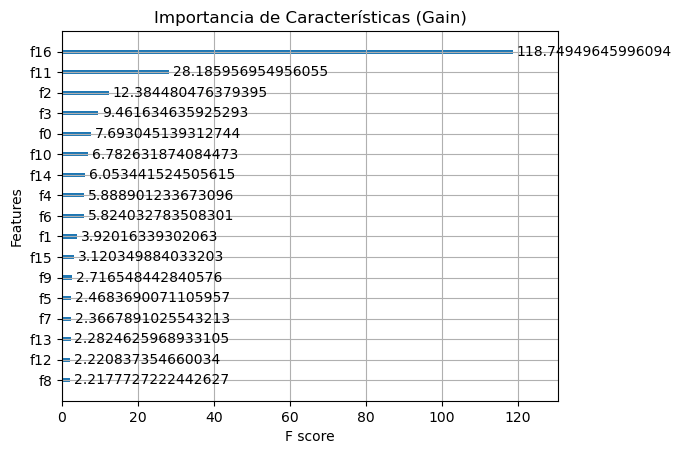

In [4]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

# Extraer el modelo entrenado desde el pipeline
xgb_model = classification_pipeline.named_steps['xgb_model']

# Importancia de características usando 'weight'
plt.figure(figsize=(10, 8))
plot_importance(xgb_model, importance_type='weight')
plt.title('Importancia de Características (Weight)')
plt.show()

# Importancia de características usando 'cover'
plt.figure(figsize=(10, 8))
plot_importance(xgb_model, importance_type='cover')
plt.title('Importancia de Características (Cover)')
plt.show()

# Importancia de características usando 'gain'
plt.figure(figsize=(10, 8))
plot_importance(xgb_model, importance_type='gain')
plt.title('Importancia de Características (Gain)')
plt.show()


Explicación de cada método de importancia:

Weight: Mide la frecuencia con la que una característica es utilizada para dividir nodos en los árboles. Es una buena referencia general, pero puede sesgarse hacia características con muchas posibles divisiones.
Cover: Representa la proporción de muestras en los nodos donde se utiliza cada característica. Refleja la cobertura de una característica en el modelo, ofreciendo una perspectiva de cuántas observaciones impacta.
Gain: Indica la mejora promedio en la precisión del modelo al usar una característica en las divisiones de los nodos. Suele reflejar mejor el impacto en el rendimiento general, pero es sensible a la escala y la variabilidad de la característica.


Compatibilidad entre los métodos: Aunque estos métodos suelen identificar características similares como importantes, sus valores pueden variar, ya que cada uno evalúa desde un enfoque diferente: weight cuenta frecuencias, cover mide cobertura de observaciones, y gain considera mejoras en precisión. Esto puede provocar discrepancias en la magnitud asignada a cada característica, especialmente si hay diferencias en la escala o redundancia entre ellas.

¿Son suficientes estas importancias para la interpretabilidad? Las importancias proporcionadas por weight, cover y gain ofrecen una visión general, pero no bastan para interpretar completamente el modelo, ya que no consideran relaciones no lineales ni interacciones entre características. Además, pueden sobrevalorar características con alta cardinalidad o numéricas. Una mejor alternativa podría incluir técnicas adicionales de interpretabilidad, como SHAP o LIME, que analizan el impacto directo de cada característica en predicciones específicas.

## 4. Métodos Agnósticos Globales (10 puntos)

<p align="center">
  <img src="https://media.tenor.com/JcRHtjVuXN8AAAAC/dr-simi-farmacias-similares.gif" width="400">
</p>

Tareas:
1. Para mitigar los problemas encontrados en la sección anterior, Dr. Simi le pide implementar un **método de permutación** que le permita observar la importancia de las features. `Nota:`Tenga cuidado con el orden de las columnas de este método. `Hint:` Puede obtener los features del clasificador con su respectivo orden mediante el método `.get_booster().feature_names` (2 puntos)
2. Para que su modelo sea consistente, repita el proceso **30 veces** y verifique la desviación estándar de sus resultados (¿Qué señala esta?). (2 puntos)
3. Visualice los resultados de este método en un gráfico. (2 puntos)
4. Además, responda las siguientes preguntas:
  - ¿Cómo mide la importancia de las features su propuesta? (1 punto)
  - ¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido? (1 punto)
  - ¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior? (1 punto)
  - Nombre y explique 3 ventajas y 3 desventajas del método implementado. (1 punto)

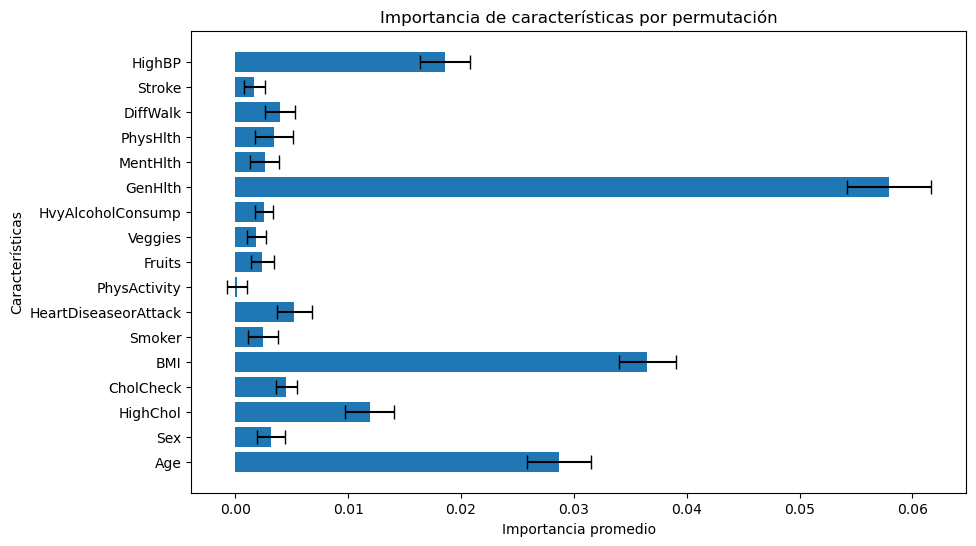

Desviación estándar de la importancia de características: [0.00286965 0.00125509 0.00216226 0.0009243  0.00252471 0.00133118
 0.00153861 0.00090691 0.00097771 0.00084615 0.00079099 0.00373304
 0.00127299 0.00164606 0.00133832 0.00093831 0.00219738]


In [5]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

permutation_results = permutation_importance(classification_pipeline, X_test, y_test, n_repeats=30, random_state=42)

mean_feature_importance = permutation_results.importances_mean
std_feature_importance = permutation_results.importances_std

plt.figure(figsize=(10, 6))
plt.barh(X_features.columns, mean_feature_importance, xerr=std_feature_importance, capsize=5)
plt.xlabel("Importancia promedio")
plt.ylabel("Características")
plt.title("Importancia de características por permutación")
plt.show()

print("Desviación estándar de la importancia de características:", std_feature_importance)


Las características con una menor desviación estándar (representadas por barras de error más pequeñas) son aquellas cuya importancia se estima de manera más consistente. Aquellas características con una alta media de importancia y baja variabilidad (baja desviación estándar) son las que el modelo considera más relevantes y confiables. Este método ofrece una evaluación sólida de la importancia al tomar en cuenta la variabilidad que surge debido al proceso aleatorio de permutación de características.

¿Cómo se calcula la importancia de las características en este método?

La metodología de permutation_importance de scikit-learn mide cómo el cambio aleatorio en cada característica afecta el rendimiento del modelo. A continuación, describo el proceso en detalle:

Se permuta cada característica de manera individual en los datos de prueba, conservando las demás sin alteraciones. Esto implica reorganizar los valores de una característica sin cambiar su relación con otras características.

Luego, se mide el rendimiento del modelo usando los datos de prueba con esta permutación. Esto permite observar el cambio en la precisión al tener una característica desordenada.

La diferencia entre el rendimiento con la característica permutada y el rendimiento original (sin permutar) cuantifica la importancia de la característica: a mayor disminución en el rendimiento, mayor es su importancia.

Este proceso se repite varias veces (según el parámetro n_repeats) para obtener una estimación robusta de la importancia. Se calcula entonces la media y desviación estándar de las importancias en todas las repeticiones para obtener una medida confiable.

¿Qué características tienen mayor impacto en el modelo?

Las cinco características principales identificadas como más influyentes son: GenHlth, HighBP, BMI, Age, y HighChol, que representan la salud general, presión arterial alta, índice de masa corporal, edad, y colesterol alto. Estas características son factores bien conocidos en la predicción de diabetes, ya que afectan directamente la probabilidad de desarrollar esta enfermedad.

Comparación con otros métodos de importancia de características

Al comparar este método de permutación con otros métodos de importancia de características (como el peso, el cover y el gain), encontramos diferencias en las características más destacadas. En los métodos anteriores, algunas de las características importantes incluyeron BMI, MentHlth, CholCheck, entre otras. Aunque hay similitudes entre los métodos, las diferencias pueden deberse a la forma en que cada técnica evalúa la importancia en el modelo. Sin embargo, todos estos enfoques resaltan características que influyen en la predicción de la diabetes, y su combinación puede ayudar a formar un panorama más completo.

Ventajas y Desventajas del Método de Permutación

Ventajas:

Aplicabilidad Amplia: Este método es altamente versátil, ya que no depende de supuestos específicos sobre la distribución de los datos o las relaciones entre variables. Esto permite que funcione con distintos tipos de modelos y conjuntos de datos.
Interpretabilidad Directa: Ofrece una interpretación intuitiva de la importancia de las características al medir cómo impacta el desorden (o permutación) de cada una en el rendimiento del modelo. Esto permite identificar fácilmente cuáles variables son críticas.
Flexibilidad en Capturar Interacciones: Este enfoque captura tanto efectos lineales como no lineales y puede reflejar interacciones entre características, brindando una visión más completa de su influencia en el modelo.


Desventajas:

Alto Consumo de Recursos: Evaluar cada característica requiere permutarla varias veces y medir el rendimiento del modelo, lo cual puede ser intensivo en cuanto a tiempo y memoria, especialmente para conjuntos de datos grandes o modelos complejos.
Sensibilidad al Modelo: La importancia de las características puede variar entre distintos modelos. Algunos modelos pueden ser más o menos sensibles a las permutaciones, lo cual puede afectar la precisión en la estimación de importancia.
Potencial para Sobrevalorar Efectos Espurios: En algunos casos, la permutación de características puede generar efectos en el rendimiento que no son causales sino debidos a relaciones espurias en los datos, especialmente si las características están altamente correlacionadas, lo que puede llevar a interpretaciones menos confiables.

## 5. Métodos Agnósticos Locales (20 puntos)

<p align="center">
  <img src="https://i.makeagif.com/media/10-24-2024/oMCrLI.gif" width="400">
</p>

### 5.1 Calculando Shap Values (4 puntos)

Tareas:
1. Alegre por saber cómo funciona el modelo de predicción a nivel general, Dr. Simi le pide ahora interpretar las predicciones de su modelo a nivel de paciente (es decir, desde un punto de vista **local**). Para esto, el ilustre farmacéutico le pide calcular los *shap values* de su modelo. (2 puntos)
2. ¿Qué representa cada número en su resultado? (1 punto)
3. ¿Es posible atribuir un significado a la positividad/negatividad de cada valor? (1 punto)

In [ ]:
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 kB 62.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 85.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 MB 38.1 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 23.1.2
[notice] To update, run: pip install --upgrade pip


In [6]:
import warnings
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")

In [16]:
import shap
# Calcular los SHAP values
explainer = shap.Explainer(classification_pipeline.named_steps['xgb_model'])
shap_values = explainer(classification_pipeline.named_steps['preprocessing'].transform(X_test))

shap_values


.values =
array([[-1.7456088 , -0.415876  ,  0.33380142, ..., -0.15234755,
        -0.00411045,  0.246965  ],
       [ 0.09380282, -0.06717047,  0.23208027, ..., -0.05702486,
        -0.02909459,  0.4515198 ],
       [ 0.27622065, -0.07349112, -0.3270603 , ...,  0.11849166,
        -0.0300687 , -0.59842426],
       ...,
       [ 0.3910395 ,  0.14138898,  0.23625004, ..., -0.06913486,
        -0.01271921,  0.44199103],
       [ 0.5352981 ,  0.15768099,  0.18336836, ..., -0.04202719,
        -0.01059032, -0.55024374],
       [-0.08664935, -0.05984485,  0.24201784, ...,  0.14405513,
         0.00737395,  0.5299573 ]], dtype=float32)

.base_values =
array([-0.00885369, -0.00885369, -0.00885369, ..., -0.00885369,
       -0.00885369, -0.00885369], dtype=float32)

.data =
array([[-1.95591422,  1.08743176,  0.95262056, ..., -0.57906149,
        -0.25700576,  0.87991818],
       [ 0.14661567, -0.91959794,  0.95262056, ..., -0.57906149,
        -0.25700576,  0.87991818],
       [ 0.14661567, -0.

¿Qué representa cada número en su resultado?

shap_values.values: Este array contiene los valores SHAP de cada característica para cada instancia (paciente). Cada número representa cuánto contribuye una característica específica a la predicción del modelo en una instancia dada. Un valor SHAP positivo sugiere que esa característica impulsa la predicción hacia la clase positiva (diabetes), mientras que un valor negativo sugiere que la característica contribuye a predecir la clase negativa (no diabetes). Esto nos permite observar cómo cada característica afecta el resultado del modelo de forma personalizada para cada paciente.

shap_values.base_values: Este array muestra el valor base o el promedio de la predicción del modelo si no se tuviera ninguna información específica del paciente. Este valor base (-0.00885369 en este caso) representa la predicción promedio del modelo en todo el conjunto de datos y está expresado en log-odds, ya que estamos utilizando un clasificador XGBoost. Este valor actúa como un punto de partida, sobre el cual se suman o restan las contribuciones individuales de cada característica (los valores SHAP) para llegar a la predicción final.

shap_values.data: Este array contiene los valores de las características reales para cada instancia en el conjunto de datos. Cada fila representa una instancia (o paciente) y cada columna, una característica particular. Estos son los datos de entrada que el modelo evalúa y sobre los cuales calcula los valores SHAP para determinar la contribución de cada característica a la predicción.

¿Es posible atribuir un significado a la positividad/negatividad de cada valor?

Sí, cada valor SHAP tiene un significado directo respecto a su efecto sobre la predicción del modelo. Un valor SHAP positivo indica que la característica está contribuyendo a que el modelo prediga la clase positiva (diabetes) con mayor probabilidad. Cuanto mayor sea este valor positivo, mayor será la influencia de esa característica en la predicción de diabetes. Por el contrario, un valor SHAP negativo sugiere que la característica reduce la probabilidad de que el modelo prediga la clase positiva. Cuanto más negativo sea el valor SHAP, mayor será la influencia de esa característica en la predicción de la clase negativa (no diabetes).

### 5.2 Aporte local (4 puntos)

1. Usando los *shap values* calculados, grafique el **aporte local** de las diferentes variables para las instancias **1**, **9** y **150** (1 punto).

2. Interprete sus resultados y responda:

  - ¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes? (1 punto)

  - ¿Existe algún patrón común entre las instancias analizadas? (1 punto)

  - ¿Es posible generalizar estas conclusiones a todo el dataset? (1 punto)

In [17]:

idx = 1
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values.values[idx, :], X_test.iloc[idx, :], link="logit")

In [18]:

idx = 9
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values.values[idx, :], X_test.iloc[idx, :], link="logit")

In [19]:

idx = 150
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values.values[idx, :], X_test.iloc[idx, :], link="logit")

¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes?

En los gráficos SHAP, las variables que aparecen en rojo aumentan la probabilidad de que el modelo prediga diabetes (contribuciones positivas), mientras que las variables en azul disminuyen dicha probabilidad (contribuciones negativas).

Para la instancia 1, las variables que aumentan la probabilidad de diabetes incluyen "HighBP" (presión arterial alta), "Age" (edad), y "GenHlth" (estado de salud general). Variables como "BMI" (índice de masa corporal) y "Sex" disminuyen la probabilidad de diabetes.

En la instancia 9, los factores como "HighBP", "HighChol" (colesterol alto), y "Age" contribuyen de manera positiva a la predicción de diabetes, mientras que el "BMI", la actividad física y la salud mental contribuyen de manera negativa.

Para la instancia 150, nuevamente se observan variables similares que aumentan la probabilidad de diabetes, como "HighChol", "HighBP" y "GenHlth", mientras que variables como "PhysHlth" (salud física) y "Age" disminuyen esta probabilidad.

¿Existe algún patrón común entre las instancias analizadas?

Sí, hay ciertos patrones comunes entre las instancias:

Las variables "HighBP" (presión arterial alta) y "HighChol" (colesterol alto) parecen ser factores consistentes que aumentan la probabilidad de predecir diabetes en las tres instancias.
La variable "BMI" (índice de masa corporal) tiende a tener un efecto negativo en algunas instancias (reduciendo la probabilidad de diabetes) dependiendo de sus valores específicos.
La variable "Age" también aparece en todas las instancias como una influencia relevante, aunque su efecto positivo o negativo puede variar según el valor específico de cada instancia.
¿Es posible generalizar estas conclusiones a todo el dataset?

No necesariamente. Los valores SHAP brindan interpretaciones específicas a nivel individual para cada instancia, basándose en el valor de cada característica en el contexto de esa observación particular. Aunque observamos patrones repetidos en estas tres instancias (como el efecto de "HighBP" y "HighChol"), no es seguro que estas mismas variables tengan el mismo efecto en todo el dataset.

### 5.3 Aporte global (4 puntos)

Genere ahora una visualización donde se grafique el aporte de cada feature a nivel **global** e interprete sus resultados. ¿Qué diferencias existen con las conclusiones generadas a nivel de instancia?

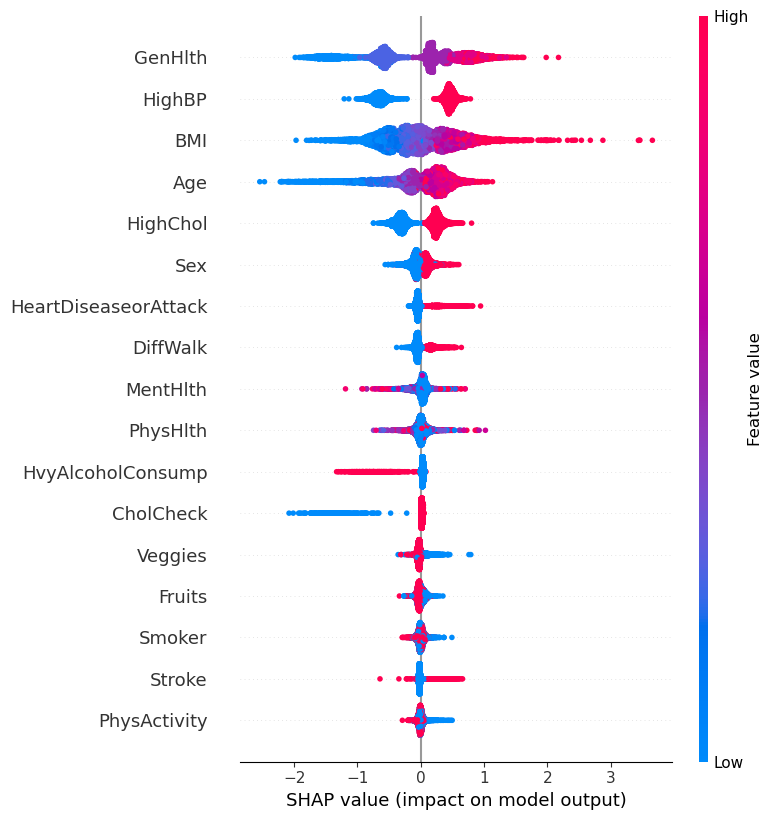

In [10]:
shap.summary_plot(shap_values.values, X_test, feature_names=X_features.columns)


Al generar el gráfico de resumen SHAP, se observa que las características más influyentes en la predicción de diabetes a nivel global son "GenHlth" (estado general de salud), "HighBP" (presión arterial alta), "BMI" (índice de masa corporal), "Age" (edad) y "HighChol" (colesterol alto). Estas características destacan por su contribución en el modelo, y se puede interpretar lo siguiente:

GenHlth: El estado general de salud tiene un impacto significativo en la predicción de diabetes. Dependiendo de si el valor de esta característica es alto o bajo, puede aumentar o disminuir la probabilidad de diabetes.
HighBP: La presión arterial alta es un predictor fuerte de diabetes, ya que los pacientes con esta condición tienen una mayor probabilidad de ser diagnosticados.
BMI: Un índice de masa corporal alto (BMI) también incrementa la probabilidad de diabetes, haciendo de esta característica un factor crucial.
Age: La edad es otro predictor importante, donde generalmente valores más altos se asocian con un mayor riesgo de diabetes.
HighChol: Los niveles altos de colesterol también tienen una contribución importante, sugiriendo que altos valores de colesterol están asociados con un mayor riesgo de diabetes.
Diferencias con las conclusiones a nivel de instancia:

La principal diferencia entre las conclusiones a nivel de instancia y a nivel global radica en la perspectiva del análisis:

A nivel de instancia: Se observa el efecto de cada característica sobre una observación específica, permitiendo identificar cómo cada valor particular de las características contribuye en la predicción individual. Esto permite interpretar si una característica aumenta o disminuye la probabilidad de diabetes para un caso específico.

A nivel global: Se obtiene una visión general de la influencia de cada característica a lo largo de todas las observaciones. En el gráfico global, se pueden ver la variabilidad y la distribución de los efectos de cada característica, destacando aquellas que consistentemente influyen más en el modelo y aquellas cuyo efecto es cercano a cero en promedio.

### 5.4 Scatter plot (4 puntos)


Grafique ahora un *scatterplot* entre los *shap values* y las primeras 5 features con mayor impacto global (un gráfico por cada feature), coloreando cada punto por la probabilidad de tener diabetes. ¿Qué puede concluir de sus resultados?

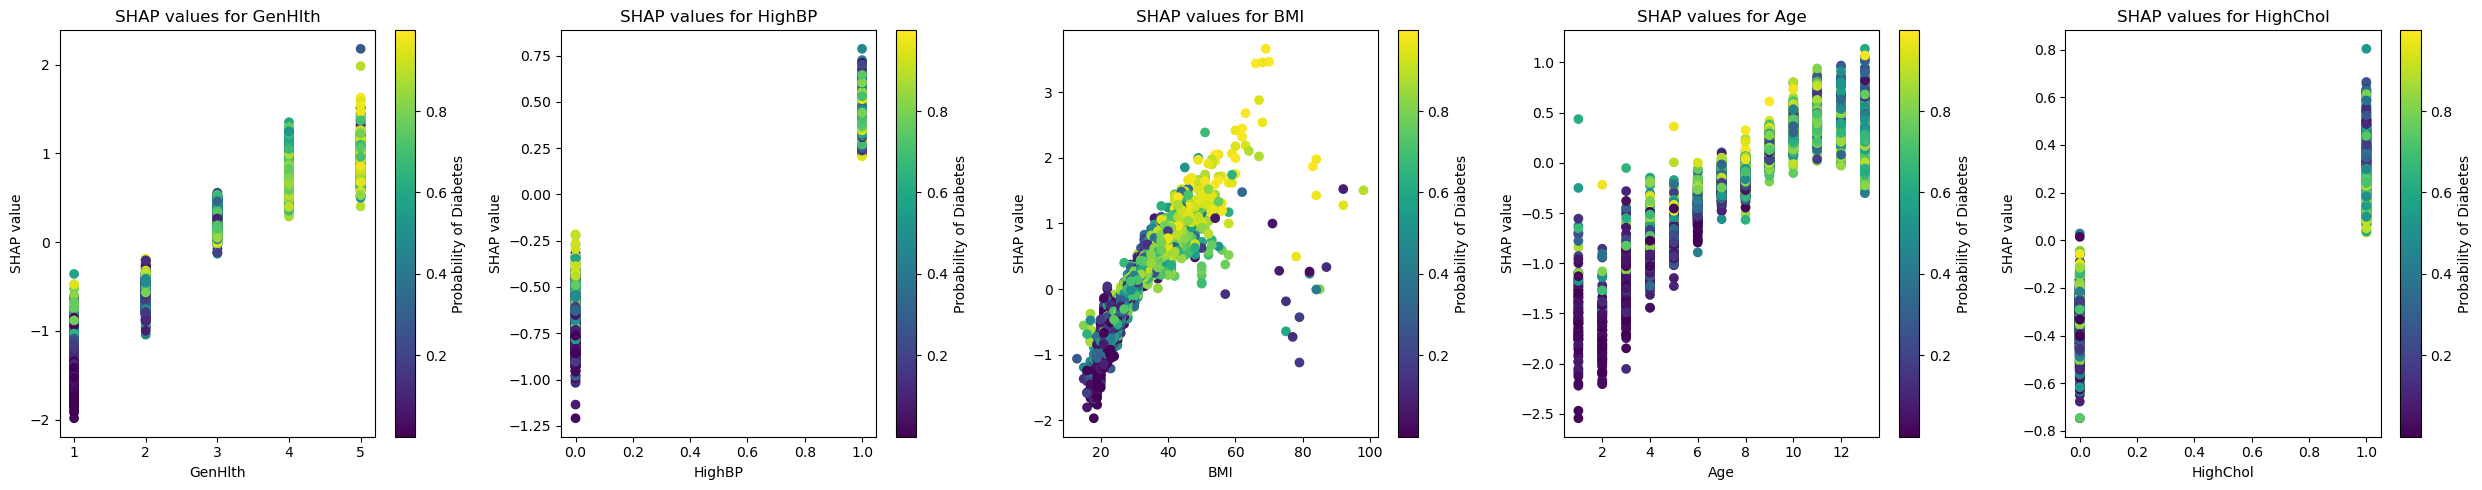

In [20]:
probdiabetes = classification_pipeline.predict_proba(X_test)[:, 1]
important_features = ['GenHlth', 'HighBP', 'BMI', 'Age', 'HighChol'] 
shap_values_array = shap_values.values
fig, axs = plt.subplots(1, 5, figsize=(25, 5))

for i, feature in enumerate(important_features):
    feature_idx = X_features.columns.get_loc(feature)
    axs[i].scatter(X_test[feature], shap_values_array[:, feature_idx], c=probdiabetes, cmap='viridis')
    axs[i].set_xlabel(feature)
    axs[i].set_ylabel('SHAP value')
    axs[i].set_title(f'SHAP values for {feature}')
    plt.colorbar(axs[i].collections[0], ax=axs[i], label='probabilidad de Diabetes')

plt.tight_layout()
plt.show()


GenHlth (Estado General de Salud): La gráfica muestra que a medida que los valores de "GenHlth" aumentan (indicando un peor estado general de salud), los valores SHAP también se incrementan. Esto sugiere que un peor estado de salud aumenta la probabilidad de tener diabetes. La relación parece ser directa, ya que a mayor "GenHlth", los valores SHAP positivos indican una mayor contribución a la predicción de diabetes.

HighBP (Presión Arterial Alta): Aquí, los valores SHAP son altos cuando "HighBP" es 1, lo que significa que tener presión arterial alta aumenta significativamente la probabilidad de diabetes. Por el contrario, cuando "HighBP" es 0, los valores SHAP son bajos o negativos, indicando una menor contribución a la probabilidad de diabetes. Este patrón muestra que la presión arterial alta es un fuerte predictor de diabetes.

BMI (Índice de Masa Corporal): Los valores SHAP aumentan con el incremento del BMI, lo cual indica que un índice de masa corporal más alto se asocia con una mayor probabilidad de diabetes. Esta relación es consistente, ya que los valores SHAP crecen de manera gradual a medida que el BMI aumenta, mostrando una correlación positiva entre BMI y riesgo de diabetes.

Age (Edad): En la gráfica de "Age", se observa una tendencia ascendente de los valores SHAP conforme aumenta la edad. Esto sugiere que a mayor edad, aumenta la probabilidad de diabetes, ya que los valores SHAP son más altos en individuos de mayor edad, indicando una contribución positiva en la predicción de la enfermedad.

HighChol (Colesterol Alto): Similar al caso de la presión arterial, los valores SHAP son altos cuando "HighChol" es 1 (colesterol alto), indicando que tener niveles elevados de colesterol aumenta la probabilidad de diabetes. En cambio, los valores SHAP son bajos o negativos cuando "HighChol" es 0, lo que implica una contribución menor o negativa en la predicción de diabetes.
Las gráficas muestran que las características "GenHlth", "HighBP", "BMI", "Age" y "HighChol" tienen una relación positiva con la probabilidad de tener diabetes. Las personas con peor estado de salud general, presión arterial alta, índice de masa corporal alto, edad avanzada y colesterol alto presentan mayores valores SHAP, lo que contribuye a una mayor probabilidad de predicción de diabetes en el modelo. Estos resultados sugieren que estos factores son cruciales para el riesgo de diabetes, y su análisis global confirma la importancia de cada característica en la predicción del modelo.

### 5.5 Partial Dependence Plot (4 puntos)

Finalmente, se le pide generar un gráfico del tipo Partial Dependence Plot para las mismas 5 variables con mayor impacto global usando una submuestra de 1000 observaciones. ¿Qué relación existe entre la salida promedio del modelo y cada feature analizada? ¿Son estas conclusiones generalizables para todo el conjunto de datos?

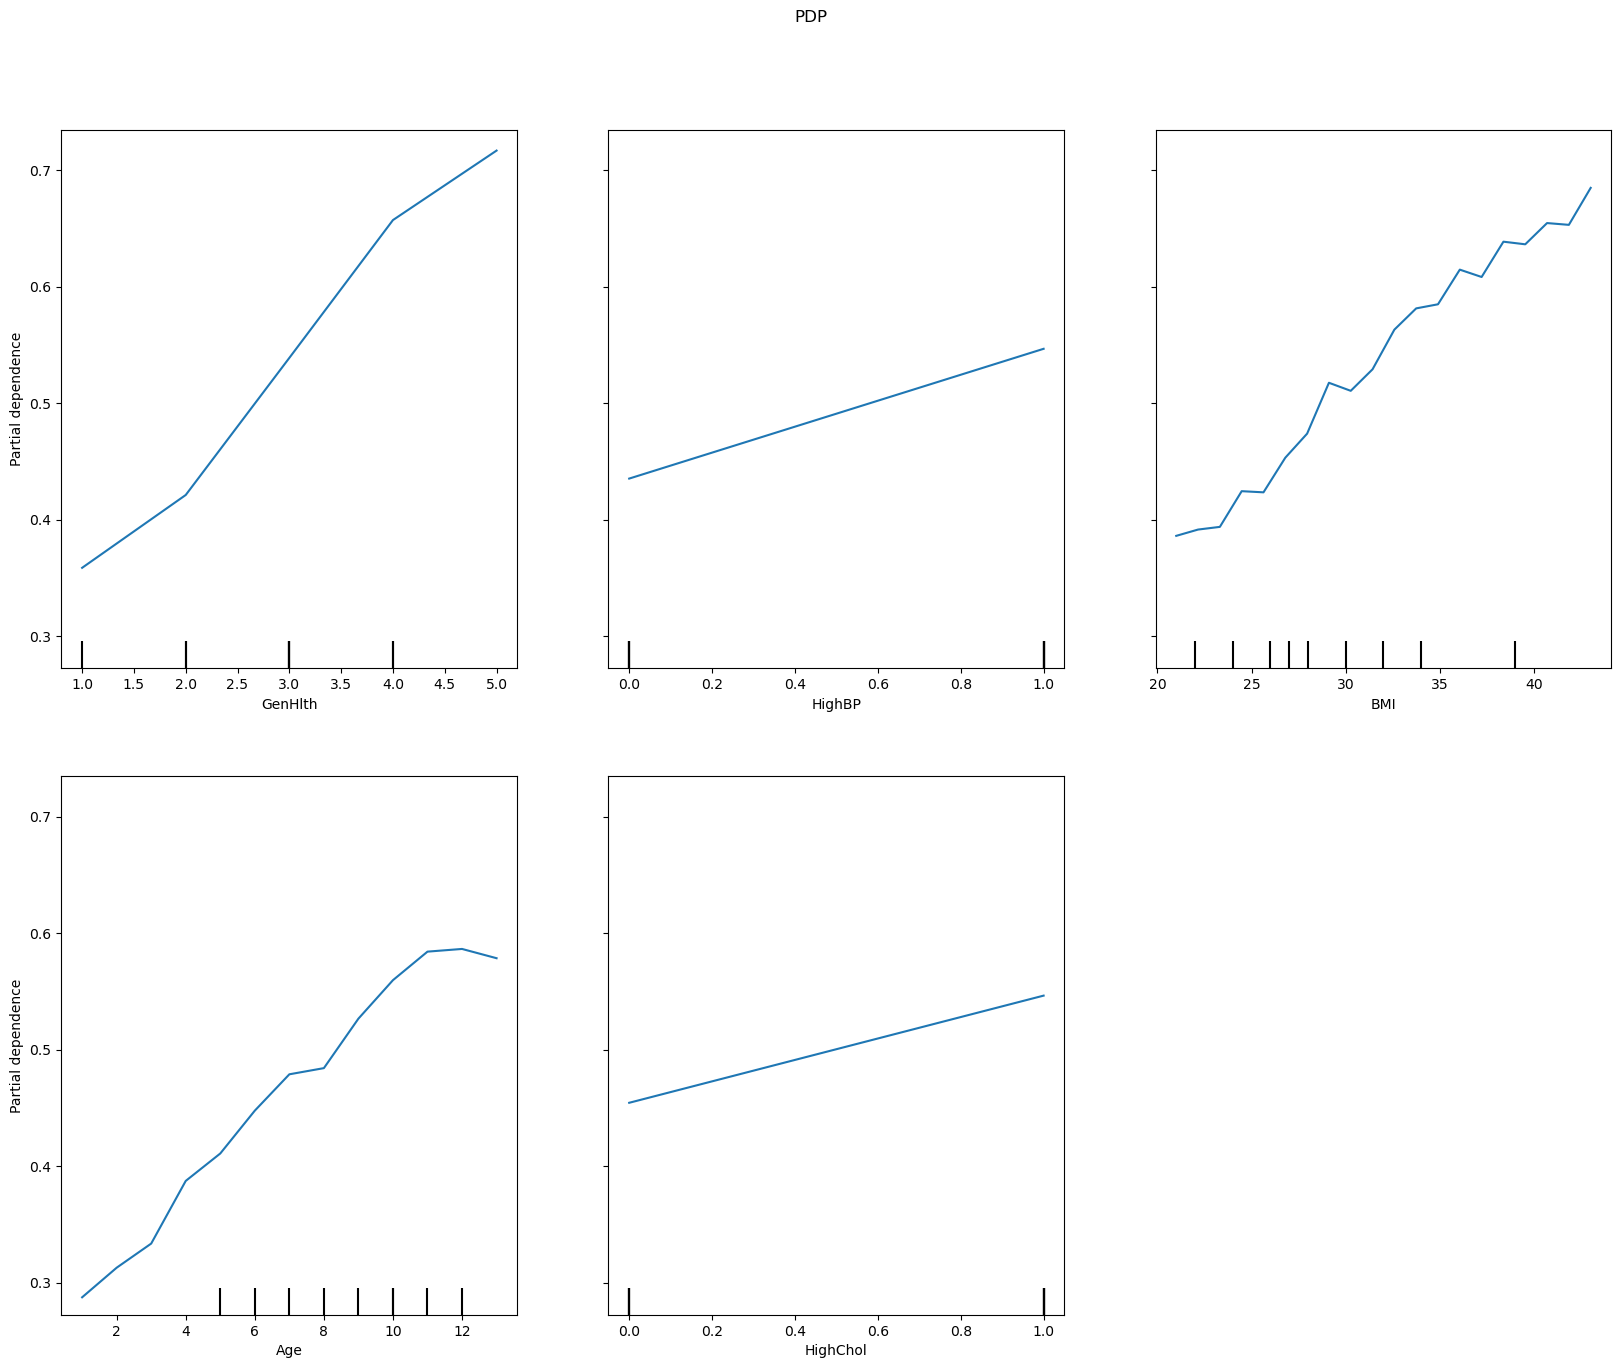

In [21]:
from sklearn.inspection import PartialDependenceDisplay


X_sample = X_test.sample(1000, random_state=42)
y_sample = y_test.loc[X_sample.index]

important_features = ['GenHlth', 'HighBP', 'BMI', 'Age', 'HighChol']

fig, ax = plt.subplots(figsize=(20, 15))
PartialDependenceDisplay.from_estimator(classification_pipeline, X_sample, features=important_features, ax=ax, grid_resolution=20)
plt.suptitle('PDP')
plt.subplots_adjust(top=0.9)  
plt.show()


GenHlth (Estado General de Salud): Existe una relación positiva entre el estado general de salud (GenHlth) y la salida del modelo, lo cual sugiere que un peor estado de salud (valores más altos en esta característica) está asociado con una mayor probabilidad de diabetes. La relación es casi lineal, lo que indica que el riesgo de diabetes aumenta de manera continua conforme empeora el estado de salud general.

HighBP (Presión Arterial Alta): En este gráfico, se observa un incremento leve en la probabilidad de diabetes cuando la variable HighBP es 1 (indica presencia de presión arterial alta). Esta característica también muestra una relación positiva, aunque más sutil, en comparación con las demás variables. La tendencia sugiere que tener presión arterial alta aumenta moderadamente la probabilidad de diabetes.

BMI (Índice de Masa Corporal): Hay una clara tendencia ascendente entre el BMI y la salida del modelo. A medida que el índice de masa corporal aumenta, también lo hace la probabilidad de diabetes de manera significativa. Esto implica que un BMI más alto está directamente relacionado con un mayor riesgo de desarrollar diabetes.

Age (Edad): La relación entre la edad y la probabilidad de diabetes es positiva y se incrementa conforme la edad aumenta, hasta cierto punto en que la curva parece estabilizarse. Esto sugiere que el riesgo de diabetes es mayor en personas mayores, aunque llega a un límite donde el efecto de la edad ya no es tan pronunciado.

HighChol (Colesterol Alto): La variable HighChol también muestra una relación positiva moderada. La probabilidad de diabetes aumenta ligeramente cuando HighChol es 1 (indica niveles altos de colesterol), aunque la variación no es tan fuerte como en las variables GenHlth, BMI o Age.

 Estos gráficos PDP muestran relaciones consistentes entre cada una de estas características y la salida promedio del modelo. Las conclusiones obtenidas son generalizables al conjunto de datos completo, ya que estos gráficos reflejan tendencias generales en las variables que afectan la probabilidad de diabetes. Dado que se utilizó una submuestra de 1000 observaciones, es razonable suponer que estos patrones se mantendrán en el conjunto de datos completo, especialmente para características con relaciones claras y lineales, como BMI y GenHlth.

## 6. Sistema de Reglas! (10 punto)

<p align="center">
  <img src="https://media.baamboozle.com/uploads/images/125978/1638281150_1380186_gif-url.gif" width="400">
</p>

Después de todo el trabajo hecho, Dr. Simi le pide simplificar el funcionamiento de su modelo en un sistema de reglas que le permita explicar a sus clientes las predicciones que genera su modelo. 
En particular, Dr. Simi le pide explicar la decisión tomada para las observaciones **1000**, **3001** y **5751**. Con las reglas propuestas señale a **cuánta población** es posible explicar con estas reglas e indique la **precisión** que poseen las reglas en la totalidad de los datos. ¿Tienen sentido sus reglas propuestas para las observaciones?. Fundamente sus respuesta señalando el impacto que tienen sus reglas sobre todo el conjunto de datos.

`Hint:` Como debe entregar las columnas que entran al clasificador entrenado de su pipeline, le será útil extraer el paso de preprocesamiento y generar dataframes preprocesados para el conjunto `train` y `test`. 

In [13]:
!pip install alibi

INFO: pip is looking at multiple versions of thinc to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of spacy[lookups] to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 18.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 1.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 2.3 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.0/865.0 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 23.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.9/796.9 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [14]:
from alibi.explainers import AnchorTabular

In [22]:
from alibi.explainers import AnchorTabular

# Define la función de predicción
def predict_fn(x):
    df_x = pd.DataFrame(x, columns=X_train.columns)
    return classification_pipeline.predict(df_x)

# Inicializa el explicador con la función de predicción y las columnas de X_train
explainer = AnchorTabular(predict_fn, X_train.columns, seed=1)
explainer.fit(X_train.to_numpy())

# Define una función para generar y mostrar la explicación de una instancia
def explain_instance(idx):
    obs = np.array(X_test.iloc[idx], ndmin=2)  
    explanation = explainer.explain(obs, threshold=0.95)
    prediction = predict_fn(obs)[0]
    anchor = ' AND '.join(explanation.anchor)

    print(f"Explicación para la observación {idx}:")
    print(f"Predicción: {prediction}")
    print(f"Anchor: {anchor}")
    print(f"Precisión: {explanation.precision}")
    print(f"Coverage: {explanation.coverage}")
    print("\n")

# Lista de índices a explicar
indices = [1000, 3001, 5751]
for idx in indices:
    explain_instance(idx)


Explicación para la observación 1000:
Predicción: 1
Anchor: GenHlth > 3.00 AND HighBP > 0.00
Precisión: 0.9508196721311475
Coverage: 0.2049


Explicación para la observación 3001:
Predicción: 1
Anchor: GenHlth > 3.00 AND HighBP > 0.00 AND HeartDiseaseorAttack > 0.00
Precisión: 0.98
Coverage: 0.0654


Explicación para la observación 5751:
Predicción: 1
Anchor: GenHlth > 3.00 AND BMI > 33.00 AND Age > 7.00
Precisión: 1.0
Coverage: 0.0668




In [ ]:
La primera regla (observación 1000) es la más generalizable, ya que afecta a una mayor parte de los datos con una precisión aceptable. Las reglas para las observaciones 3001 y 5751, aunque más precisas, son menos aplicables a la población general debido a su menor cobertura.

En términos de lógica, las reglas tienen sentido, ya que utilizan variables clave identificadas previamente (como GenHlth, HighBP, BMI) y alinean con los factores importantes para la predicción del modelo. Esto asegura que las reglas sean relevantes tanto para los casos individuales como para el conjunto de datos completo, brindando explicaciones coherentes con el comportamiento general del modelo.

# Retrospectiva... (10 puntos)

En base a los diferentes métodos que implementa y ha comentado en este laboratorio, comente qué métodos le permiten entregar mejores conclusiones para la tarea de clasificación de diabetes. Por otro lado, ¿qué métodos son más útiles para el problema del doctor Simi, métodos agnosticos locales o globales?

> Fundamente su Respuesta aquí


Para abordar la tarea de clasificación de diabetes, los métodos agnósticos resultan especialmente efectivos porque proporcionan insights que no dependen del modelo específico utilizado. Estos métodos son útiles para comprender mejor cómo cada característica influye en las predicciones.

En este contexto, los métodos locales que se pueden interpretar de manera global, como SHAP, son los más recomendables. SHAP permite descomponer las predicciones individuales y detallar el impacto de cada característica en la probabilidad de pertenecer a una clase específica. Esto no solo revela cómo los valores particulares de las características afectan las predicciones, sino que también ayuda a identificar las características más relevantes en general, ofreciendo una perspectiva detallada y útil.

En cuanto al problema del doctor Simi, los métodos agnósticos son preferibles. Sin embargo, la elección entre métodos locales y globales dependerá de la necesidad específica de análisis. Para obtener una visión granular de cómo cada característica influye en casos particulares, los métodos locales (pero presentados globalmente) aportan más valor al mostrar patrones e interacciones detalladas de las variables clave en el proceso de clasificación.

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

![Gracias Totales!](https://media.tenor.com/ctnq4bhZE3gAAAAC/drsimi-simi.gif)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>